In [106]:
import pandas as pd
data = pd.read_csv('BostonHousing.csv')
# data.head()
# data.isnull().sum()

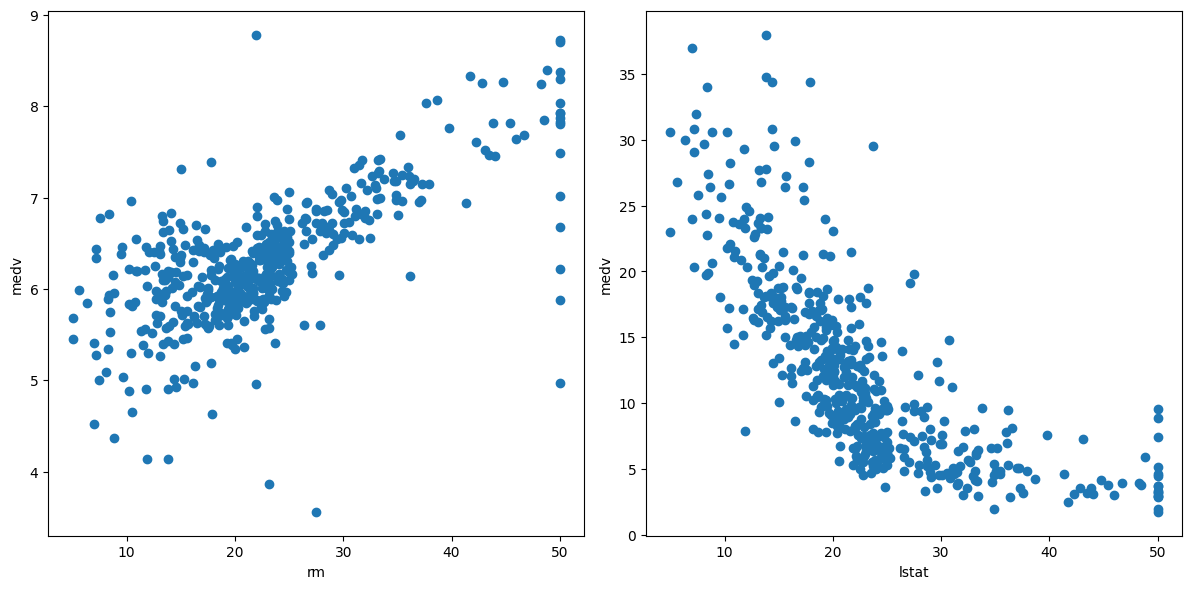

In [112]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.xlabel('rm')
plt.ylabel('medv')
plt.scatter(data['medv'], data['rm'])

plt.subplot(1, 3, 2)
plt.xlabel('lstat')
plt.ylabel('medv')
plt.scatter(data['medv'], data['lstat'])

plt.tight_layout()
plt.show()

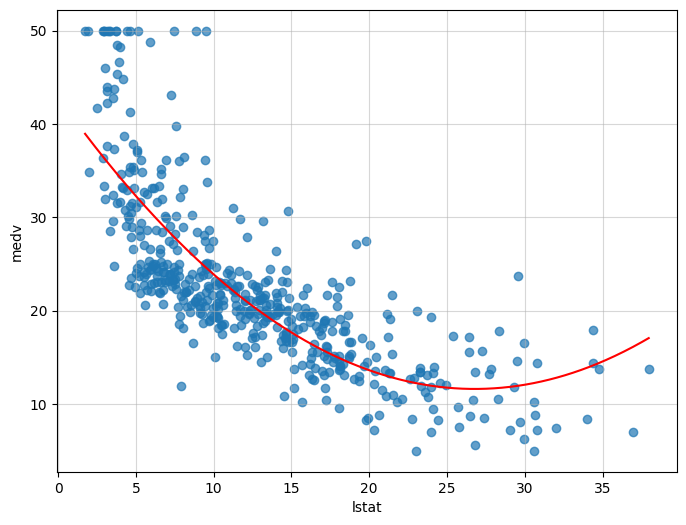

In [115]:
from numpy.polynomial.polynomial import Polynomial
import numpy as np

# Fit a quadratic curve to the original LSTAT and MEDV
x_original = data['lstat']
y_original = data['medv']

# Fit a polynomial of degree 2
coeffs_original = Polynomial.fit(x_original, y_original, deg=2)

# Generate fitted values for the original scale
x_fit_original = np.linspace(x_original.min(), x_original.max(), 500)
y_fit_original = coeffs_original(x_fit_original)

# Plot the scatter plot with the fitted curve for the original scale
plt.figure(figsize=(8, 6))
plt.scatter(x_original, y_original, alpha=0.7)
plt.plot(x_fit_original, y_fit_original, color ='red')
plt.xlabel('lstat')
plt.ylabel('medv')

plt.grid(True, alpha=0.5)
plt.show()


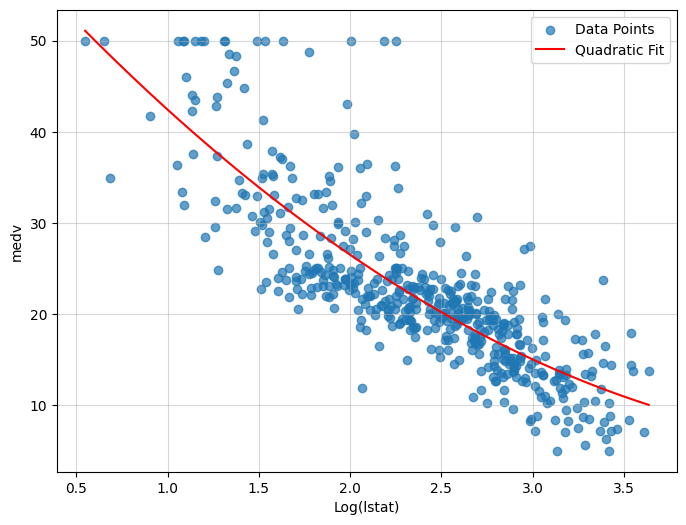

In [117]:
# Import library for curve fitting
from numpy.polynomial.polynomial import Polynomial
import numpy as np

data['log_lstat'] = np.log(data['lstat'])
# Fit a quadratic curve to the log-transformed LSTAT and MEDV
x = data['log_lstat']
y = data['medv']

# Fit a polynomial of degree 2
coeffs = Polynomial.fit(x, y, deg=2)

# Generate fitted values
x_fit = np.linspace(x.min(), x.max(), 500)
y_fit = coeffs(x_fit)

# Plot the scatter plot with the fitted curve
plt.figure(figsize=(8, 6))
plt.scatter(x, y, alpha=0.7, label='Data Points')
plt.plot(x_fit, y_fit, color='red', label='Quadratic Fit')
plt.xlabel('Log(lstat)')
plt.ylabel('medv')
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()


In [108]:
import statsmodels.api as sm

X1 = data[['rm', 'lstat']]
y = data['medv']
X1 = sm.add_constant(X1)
model1 = sm.OLS(y, X1).fit()

model1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   medv   R-squared:                       0.639
Model:                            OLS   Adj. R-squared:                  0.637
Method:                 Least Squares   F-statistic:                     444.3
Date:                Wed, 01 Jan 2025   Prob (F-statistic):          7.01e-112
Time:                        13:23:43   Log-Likelihood:                -1582.8
No. Observations:                 506   AIC:                             3172.
Df Residuals:                     503   BIC:                             3184.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.3583      3.173     -0.428      0.669      -7.592       4.875
rm             5.0948      0.444     11.463      0.000       4.222       5.968
lstat         -0.6424      0.044    -14.689      0.000      -0.728      -0.556
==============================================================================
Omnibus:                      145.712   Durbin-Watson:                   0.834
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              457.690
Skew:                           1.343   Prob(JB):                    4.11e-100
Kurtosis:                       6.807   Cond. No.                         202.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

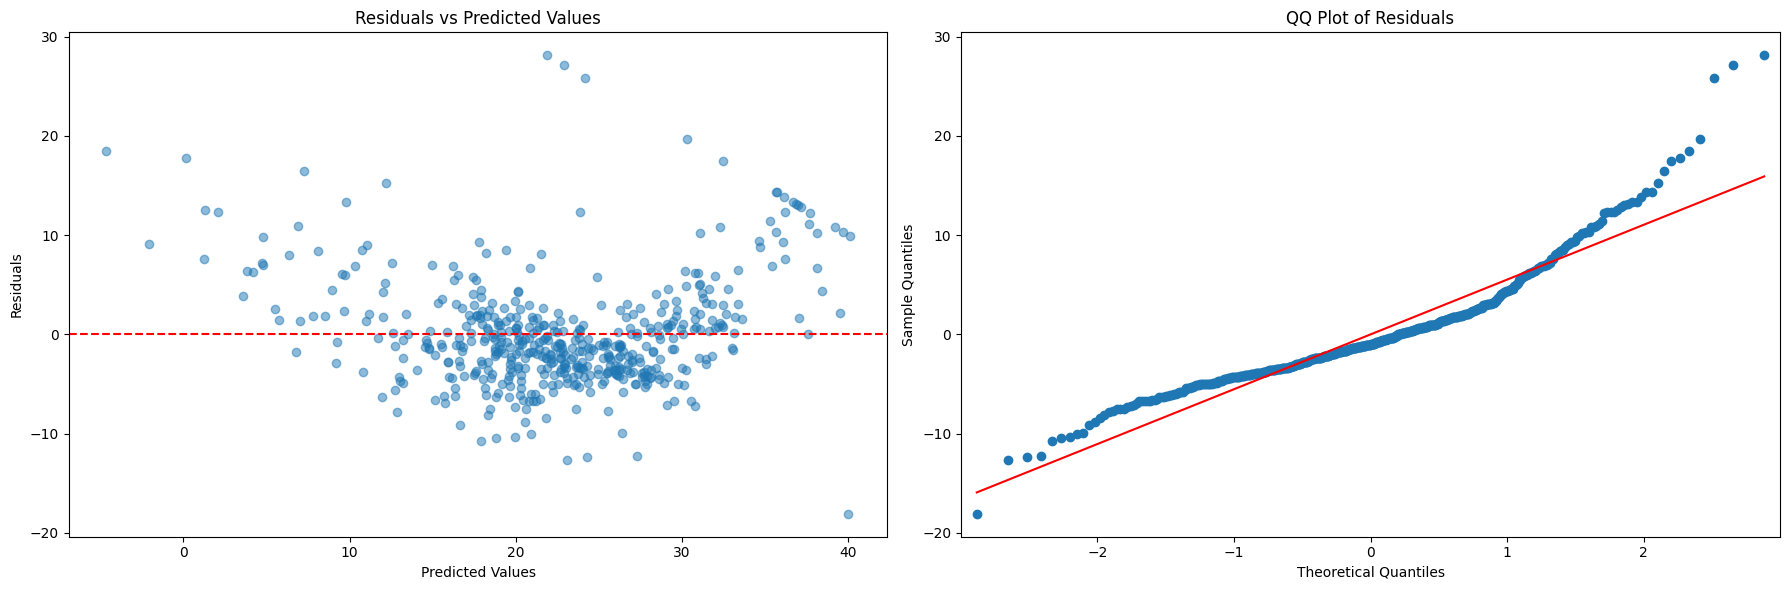

In [120]:
# 重新載入必要的程式庫與資料
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.gofplots import qqplot
import statsmodels.api as sm

plt.figure(figsize=(18, 6))

predictions1 = model1.predict(X1)
residuals1 = y - predictions1

plt.subplot(1, 2, 1)
plt.scatter(predictions1, residuals1, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals vs Predicted Values')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')

plt.subplot(1, 2, 2)
qqplot(residuals1, line='s', ax=plt.gca())
plt.title('QQ Plot of Residuals')

# 顯示圖形
plt.tight_layout()
plt.show()


In [110]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["Variable"] = X1.columns
vif_data["VIF"] = [variance_inflation_factor(X1.values, i) for i in range(X1.shape[1])]
vif_data

,Variable,VIF
0,const,165.952438
1,rm,1.604520
2,lstat,1.604520


In [111]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score


# 分割資料為訓練集與測試集 (80% 訓練，20% 測試)
X_train, X_test, y_train, y_test = train_test_split(X1, y, test_size=0.2, random_state=42)

# 初始化線性回歸模型
model = LinearRegression()

# 交叉驗證 (10-fold)
cross_val_scores = cross_val_score(model, X_train, y_train, cv=10, scoring='r2')

# 在訓練集上擬合模型
model.fit(X_train, y_train)

# 在測試集上進行預測
y_pred = model.predict(X_test)

# 計算測試集上的 R^2
test_r2 = r2_score(y_test, y_pred)

# 結果整理
results = {
    "Cross-Validation R^2 Scores": cross_val_scores.tolist(),
    "Mean CV R^2": cross_val_scores.mean(),
    "Test Set R^2": test_r2
}

results

{'Cross-Validation R^2 Scores': [0.5902720787470499,
  0.6949623849045397,
  0.7250832625366102,
  0.2015134934811188,
  0.7349644356438938,
  0.6045558782365218,
  0.750810315310884,
  0.6417489751729759,
  0.6942023321466473,
  0.41898685302476024],
 'Mean CV R^2': 0.6057100009205001,
 'Test Set R^2': 0.573957741502586}

In [118]:
import statsmodels.api as sm

X2 = data[['rm', 'log_lstat']]
y = data['medv']
X2 = sm.add_constant(X2)
model2 = sm.OLS(y, X2).fit()

model2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   medv   R-squared:                       0.707
Model:                            OLS   Adj. R-squared:                  0.706
Method:                 Least Squares   F-statistic:                     607.2
Date:                Wed, 01 Jan 2025   Prob (F-statistic):          7.40e-135
Time:                        14:07:48   Log-Likelihood:                -1529.6
No. Observations:                 506   AIC:                             3065.
Df Residuals:                     503   BIC:                             3078.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         22.8865      3.552      6.443      0.000      15.908      29.865
rm             3.5977      0.423      8.512      0.000       2.767       4.428
log_lstat     -9.6855      0.494    -19.597      0.000     -10.656      -8.714
==============================================================================
Omnibus:                      130.413   Durbin-Watson:                   0.850
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              421.915
Skew:                           1.185   Prob(JB):                     2.41e-92
Kurtosis:                       6.794   Cond. No.                         111.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

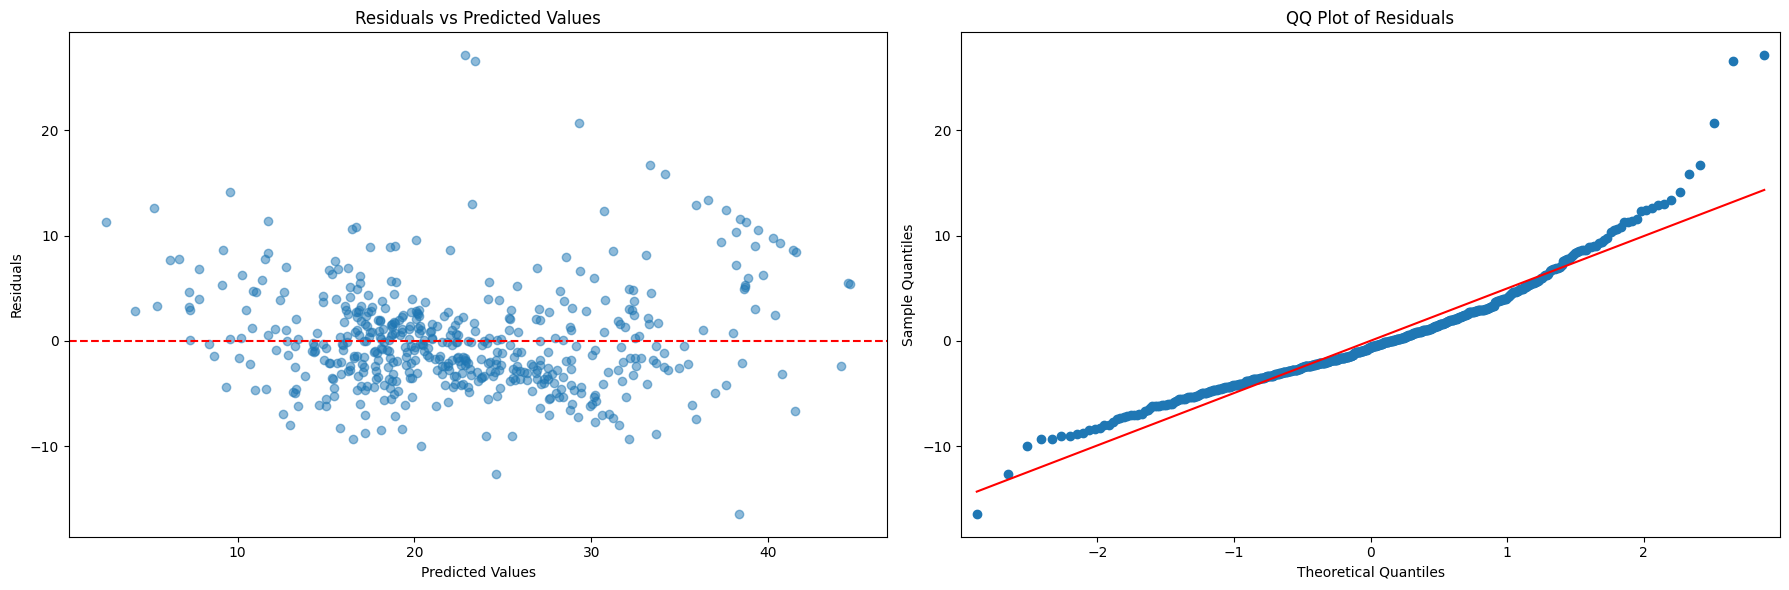

In [119]:
# 重新載入必要的程式庫與資料
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.gofplots import qqplot
import statsmodels.api as sm

plt.figure(figsize=(18, 6))

predictions2 = model2.predict(X2)
residuals2 = y - predictions2

plt.subplot(1, 2, 1)
plt.scatter(predictions2, residuals2, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals vs Predicted Values')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')

plt.subplot(1, 2, 2)
qqplot(residuals2, line='s', ax=plt.gca())
plt.title('QQ Plot of Residuals')

# 顯示圖形
plt.tight_layout()
plt.show()

In [121]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
import numpy as np

# Split data into predictors (X) and target (y)
X3 = data.drop(columns=['medv'])
y = data['medv']

# Standardize the predictors
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X3)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Fit LASSO with cross-validation
lasso = LassoCV(cv=5, random_state=42).fit(X_train, y_train)

# Get coefficients and identify selected variables
lasso_coefficients = lasso.coef_
selected_features = X3.columns[np.abs(lasso_coefficients) > 1e-5]

# Create a summary of the results
lasso_results = pd.DataFrame({
    'Feature': X3.columns,
    'Coefficient': lasso_coefficients
}).sort_values(by='Coefficient', key=abs, ascending=False)

lasso_results

,Feature,Coefficient
13,log_lstat,-7.254303
7,dis,-2.541380
12,lstat,2.150527
8,rad,2.101187
5,rm,2.026727
10,ptratio,-1.772265
4,nox,-1.742889
9,tax,-1.531310
0,crim,-1.140942
11,b,0.915636


In [105]:
import pandas as pd
import statsmodels.api as sm

# 定義數據
X1 = data[['rm', 'tax', 'ptratio', 'lstat', 'medv']]

# 描述性統計
desc = X1.describe().round(2)
MEDV_Q3 = desc['medv']['75%']
MEDV_Q1 = desc['medv']['25%']
MEDV_IQR = MEDV_Q3 - MEDV_Q1
MEDV_UV = MEDV_Q3 + 1.5 * MEDV_IQR
MEDV_LV = MEDV_Q1 - 1.5 * MEDV_IQR

# 剔除目標變數的異常值
data2 = X1[(X1['medv'] >= MEDV_LV) & (X1['medv'] <= MEDV_UV)]

# 計算平均稅率
tax_10 = data2[(data2['tax'] < 600) & (data2['lstat'] >= 0) & (data2['lstat'] < 10)]['tax'].mean()
tax_20 = data2[(data2['tax'] < 600) & (data2['lstat'] >= 10) & (data2['lstat'] < 20)]['tax'].mean()
tax_30 = data2[(data2['tax'] < 600) & (data2['lstat'] >= 20) & (data2['lstat'] < 30)]['tax'].mean()
tax_40 = data2[(data2['tax'] < 600) & (data2['lstat'] >= 30)]['tax'].mean()

# 更新稅率
indexes = list(data2.index)
for i in indexes:
    if data2.loc[i, 'tax'] > 600:
        if (0 <= data2.loc[i, 'lstat'] < 10):
            data2.loc[i, 'tax'] = tax_10
        elif (10 <= data2.loc[i, 'lstat'] < 20):
            data2.loc[i, 'tax'] = tax_20
        elif (20 <= data2.loc[i, 'lstat'] < 30):
            data2.loc[i, 'tax'] = tax_30
        elif (data2.loc[i, 'lstat'] > 30):
            data2.loc[i, 'tax'] = tax_40

# 移除多行
data3 = data2.drop(index=[365, 367, 364], axis=0)

# 建模
y = data3['medv']
X2 = sm.add_constant(data3.drop(columns='medv'))  # 添加截距項
model = sm.OLS(y, X2).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                   medv   R-squared:                       0.713
Model:                            OLS   Adj. R-squared:                  0.710
Method:                 Least Squares   F-statistic:                     283.9
Date:                Tue, 31 Dec 2024   Prob (F-statistic):          1.65e-122
Time:                        04:26:27   Log-Likelihood:                -1231.9
No. Observations:                 463   AIC:                             2474.
Df Residuals:                     458   BIC:                             2494.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         32.2350      3.207     10.051      0.0

C:\Users\USER\AppData\Local\Temp\ipykernel_24492\2764609622.py:31: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '334.33088235294116' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data2.loc[i, 'tax'] = tax_20


In [ ]:
# data.info()

In [ ]:
# data.isnull().sum()

In [ ]:
# pip install matplotlib==3.7.3 --user


In [ ]:
# pip show matplotlib

In [ ]:
# y = data['medv']
# import seaborn as sns
# import matplotlib.pyplot as plt
# sns.histplot(y)

In [ ]:
# plt.figure(figsize=(12, 10))
# corr_matrix = data.corr().round(2)
# sns.heatmap(data = corr_matrix, cmap='coolwarm' , annot = True)
# plt.show()

In [ ]:
X1 = data[['nox', 'rm', 'tax', 'ptratio', 'lstat', 'medv']]
X1

In [75]:
# import statsmodels.api as sm

# X1 = data[['nox', 'rm', 'tax', 'ptratio', 'lstat', 'medv']]
# y = data['medv']
# model = sm.OLS(y, X1).fit()

# model.summary()

In [ ]:
import statsmodels.api as sm

X1 = data.drop(columns='medv')
y = data['medv']
model = sm.OLS(y, X1).fit()

# model.summary()

In [ ]:
import statsmodels.api as sm

X1 = data[['rm', 'tax', 'ptratio', 'lstat']]
y = data['medv']
model = sm.OLS(y, X1).fit()

# model.summary()

In [ ]:
desc = X1.describe().round(2)
desc

In [95]:
MEDV_Q3 = desc['medv']['75%']
MEDV_Q1 = desc['medv']['25%']
MEDV_IQR = MEDV_Q3 - MEDV_Q1
MEDV_UV = MEDV_Q3 + 1.5*MEDV_IQR
MEDV_LV = MEDV_Q1 - 1.5*MEDV_IQR

data2 = X1[~(X1['medv']==50)]


In [ ]:
tax_10 = data2[(data2['tax']<600) & (data2['lstat']>=0) & (data2['lstat']<10)]['tax'].mean()
tax_20 = data2[(data2['tax']<600) & (data2['lstat']>=10) & (data2['lstat']<20)]['tax'].mean()
tax_30 = data2[(data2['tax']<600) & (data2['lstat']>=20) & (data2['lstat']<30)]['tax'].mean()
tax_40 = data2[(data2['tax']<600) & (data2['lstat']>=30)]['tax'].mean()

indexes = list(data2.index)
for i in indexes:
    if data2['tax'][i] > 600:
        if (0 <= data2['lstat'][i] < 10):
            data2.at[i,'tax'] = tax_10
        elif (10 <= data2['lstat'][i] < 20):
            data2.at[i,'tax'] = tax_20
        elif (20 <= data2['lstat'][i] < 30):
            data2.at[i,'tax'] = tax_30
        elif (data2['lstat'][i] >30):
            data2.at[i,'tax'] = tax_40

print('Values imputed successfully')

In [ ]:
sns.histplot(data2['tax'])


In [98]:
data3 = data2.drop(axis=0,index=[365,367])
data3 = data3.drop(axis=0,index=[364])
data3 = data3.drop(axis=0,index=[179, 182, 180])



In [ ]:
data3.info()

In [ ]:
import statsmodels.api as sm

X2 = data3.drop(columns='medv')
X2

In [ ]:
X2 = sm.add_constant(X2)
model = sm.OLS(y, X2).fit()
model.summary()

In [ ]:
import statsmodels.api as sm
model = sm.OLS(y, X[['rm', 'lstat']]).fit()
model.summary()

In [ ]:
# 必須重新載入需要的資料和庫
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV

# 載入 Boston Housing 資料集
boston_data = pd.read_csv('BostonHousing.csv')

# 分離特徵與目標變數
X = boston_data.drop(columns=['medv'])  # 假設目標變數欄位為 "medv"
y = boston_data['medv']

# 標準化特徵
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  # 對特徵進行標準化

# 設置 LASSO 模型及超參數範圍
parameters = {'alpha': [0.01, 0.1, 1, 10]}  # 不同的正則化強度
lasso_cv = GridSearchCV(Lasso(max_iter=10000), param_grid=parameters, cv=5)  # 5 折交叉驗證
lasso_cv.fit(X_scaled, y)

# 最佳 alpha 值
best_alpha = lasso_cv.best_params_['alpha']

# 使用最佳模型提取特徵
selected_features = [feature for feature, coef in zip(X.columns, lasso_cv.best_estimator_.coef_) if coef != 0]
coefficients = lasso_cv.best_estimator_.coef_

selected_features